# FSCI 396: Structural Equation Modelling

------------------
Welcome to today's tutorial! 
Today we'll use Python in Jupyter Notebook to perform some common statistical analyses.
We will cover: Structural Equation Modelling

The goal is to see how we can analyze data with Python, just like we discussed in lectures.


### Steps to Debugging 

I am here to help you! But before you contact me, make sure you have tried the following:
1. Ensure that all brackets and parentheses are paired.
2. Ensure that your code does not have any typos (eg. when calling your data file).
3. Ensure you did not add additional spaces (eg. when calling your data file).
4. You have restarted your kernel and reun your code. 
5. You have tried to understand the error message. 

If you have done all of these things, I am very happy to help! 

In [1]:
# Import Modules
# ---------------

# Modules in Python are like library books. 
# Each book contains a set of instructions or “recipes” for doing specific tasks.
# - pandas: for handling and analyzing tables of data
# - semopy: used for structural equation modelling 

import pandas as pd
import semopy

# Ignore Warnings for simplicity
import warnings
warnings.filterwarnings('ignore')

# Quick check to see if modules loaded correctly
print("Modules loaded successfully!")


Modules loaded successfully!


In [2]:
# Load datafile/dataframe (df) from CSV
# --------------------------------------

# Here we load our data. Make sure the CSV file is in the same folder as this notebook.

# If your data is .csv, use these two lines: 
filename = 'SampleData.csv'    # Name of your file
df = pd.read_csv(filename)         # Read the CSV into a DataFrame

# Checkpoint to ensure the file has been loaded 
print(filename, 'has been loaded')


Anon_Compiled_Qual_2024-2025_Grades.xlsx has been loaded


In [3]:
df.columns

Index(['Unnamed: 0', 'CW1', 'CW2', 'CW3', 'EM1', 'EM2', 'EM3', 'EM4', 'DS1',
       'DS2', 'DS3', 'DS4', 'DS5', 'AnxTest1', 'AnxTest2', 'AnxTest3',
       'AnxWrit1', 'AnxWrit2', 'AnxWrit3', 'AnxPres1', 'AnxPres2', 'AnxPres3',
       'AnxGrp1', 'AnxGrp2', 'AnxGrp3', 'R1', 'R2', 'R3', 'R4', 'E1', 'E2',
       'E3', 'E4', 'E5', 'E6', 'SE1', 'SE2', 'SE3', 'SE4', 'SE5', 'SE6', 'SE7',
       'SE8', 'PredictedGrade', 'Degree', 'Citizenship', 'YearOfStudy',
       'Field', 'McGillLearningStratParticipation', 'Gender', 'YoB', 'Credits',
       'Disability', 'Minority', 'FirstGen', 'Grade', 'CognitiveWorry',
       'Emotionality', 'Distraction', 'Rehearsal', 'Elaboration',
       'State_Anxiety', 'SelfEfficacy', 'Anxiety_test', 'Anxiety_writing',
       'Anxiety_speaking', 'Anxiety_group', 'semester', 'Course', 'Qual2_Anon',
       'Qual1_Anon'],
      dtype='object')

# Structural Equation Modelling (SEM)

Structural Equation Modelling (SEM) is used to test/validate multiple relationships at once, including both direct and indirect effects. SEM can include both observed variables and latent (unobserved) variables, which are inferred from measured indicators. Like ANOVA and regression, SEM is used to explain variation in outcome variables, but it does so by evaluating an entire system of relationships simultaneously.

SEM can be thought of as a generalization of regression that also incorporates elements of factor analysis (combining/factoring multiple variables down into one). Variables in SEM may act as both predictors and outcomes, depending on their position in the model.


For example, we could use regression to analyze the direct effect of: anxiety --> Distraction. 
But we can also see the indirect affect that anxiety has through self efficiacy: anxiety --> self effiicacy --> Distraction 


- **Interpretation**: individual path estimates tell you how variables are related, while model fit indices tell you how well the entire model represents the data.
    - *"Estimate" / "Std. Estimate" --> Path coefficient: strength and direction of the relationship between two variables.*
              *Larger absolute values indicate stronger effects.*
    - *"SE"       --> Standard Error, uncertainty associated with the path estimate.*
    - *"z"        --> z-statistic: ratio of the estimate to its standard error.*
    - *"p-value"  --> Probability that the observed path would occur if there were no true relationship.*
              *Low p (< .05) → the path significantly contributes to the model.*
    - *"Variance" / "Residual" --> Unexplained variance remaining after accounting for predictors.*
              *Smaller residual variance indicates better explanatory power.*


- **Model Fit (overall evaluation)**:
    - *"CFI / TLI"       --> Comparative fit indices comparing the model to a null model.*
              *Values ≥ .95 indicate good fit.*
    - *"RMSEA"          --> Approximate fit per degree of freedom.*
              *Values ≤ .06 indicate good fit.*

- **Quick Translation**

     *Path coefficient + p-value --> “Does this specific relationship matter?”*\
     *Standardized estimates     --> “Which relationships are strongest?”*\
     Residual variances         --> “How much variance is left unexplained?”*\
     Model fit indices          --> “Does the overall model make sense?”*


In [4]:
# We had many ways of choosing a specific grouping of our dataframe. 
# Name it here

df = df

In [26]:
desc = """

# # Structural (regression) paths
# Put the predicted variable first, tilde (~) represents regression; the predictors go on the right of the tilde
State_Anxiety ~ Rehearsal + Elaboration
SelfEfficacy ~ State_Anxiety + Rehearsal + Elaboration

# Latent variables (factor measurement models)
# These define unobserved constructs using multiple observed indicators
Rehearsal =~ R1 + R2 + R3 + R4
Elaboration =~ E1 + E2 + E3 + E4 + E5 + E6  #original 
# Elaboration =~  E2 + E3 + E6  # Sotardi method
Elaboration =~ E1 + E2 + E3 + E5  # mine

CW =~ CW1 + CW2 + CW3 
EM =~ EM1 + EM2 + EM3 + EM4
DS =~ DS1 + DS2 + DS3 + DS4 + DS5 
State_Anxiety =~ CW + EM + DS
# State_Anxiety =~ CW1 + CW2 + CW3 + EM1 + EM2 + EM3 + EM4 + DS1 + DS2 + DS3 + DS4 + DS5 
SelfEfficacy =~ SE1 + SE2 + SE3 + SE4 + SE5 + SE6 + SE7 +SE8

# Additional covariances
Rehearsal ~~  Elaboration

"""

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


# Build and fit the model
model = semopy.Model(desc)
model.fit(df)

# Calculate fit statistics
stats = semopy.calc_stats(model)

# Print specific indices
print("CFI:", stats["CFI"].values[0])
print("RMSEA:", stats["RMSEA"].values[0])
print("TLI:", stats["TLI"].values[0])

# # Inspect results
# print(model.inspect(std_est=True))

CFI: 0.9016703122832458
RMSEA: 0.07333380535010044
TLI: 0.8919863278868989


In [6]:
# Get standardized estimates
est_std = model.inspect(std_est=True)

# Show structural paths only
structural_std = est_std[est_std['op'] == '~']
print("Standardized betas for structural paths:\n")
print(structural_std[['lval','rval','Est. Std','p-value']])

# Approximate R² for latent endogenous variables
endogenous = ["State_Anxiety", "SelfEfficacy"]
r2_values = {}

for y in endogenous:
    # Sum of squared standardized betas for predictors of this variable
    preds = structural_std[structural_std['lval'] == y]
    r2_values[y] = (preds['Est. Std']**2).sum()

print("\nApproximate R² for latent variables:")
print(r2_values)


Standardized betas for structural paths:

             lval           rval  Est. Std   p-value
0   State_Anxiety      Rehearsal  0.208475  0.000004
1   State_Anxiety    Elaboration  0.073015  0.083797
2    SelfEfficacy  State_Anxiety -0.568908       0.0
3    SelfEfficacy      Rehearsal  0.035197  0.344211
4    SelfEfficacy    Elaboration  0.080981  0.026485
5              R1      Rehearsal  0.678933         -
6              R2      Rehearsal  0.671813       0.0
7              R3      Rehearsal  0.813790       0.0
8              R4      Rehearsal  0.613719       0.0
9              E1    Elaboration  0.541901         -
10             E2    Elaboration  0.585412       0.0
11             E3    Elaboration  0.611660       0.0
12             E4    Elaboration  0.445846       0.0
13             E5    Elaboration  0.744122       0.0
14             E6    Elaboration  0.781103       0.0
15            CW1  State_Anxiety  0.421667         -
16            CW2  State_Anxiety  0.522485       0.0
17  

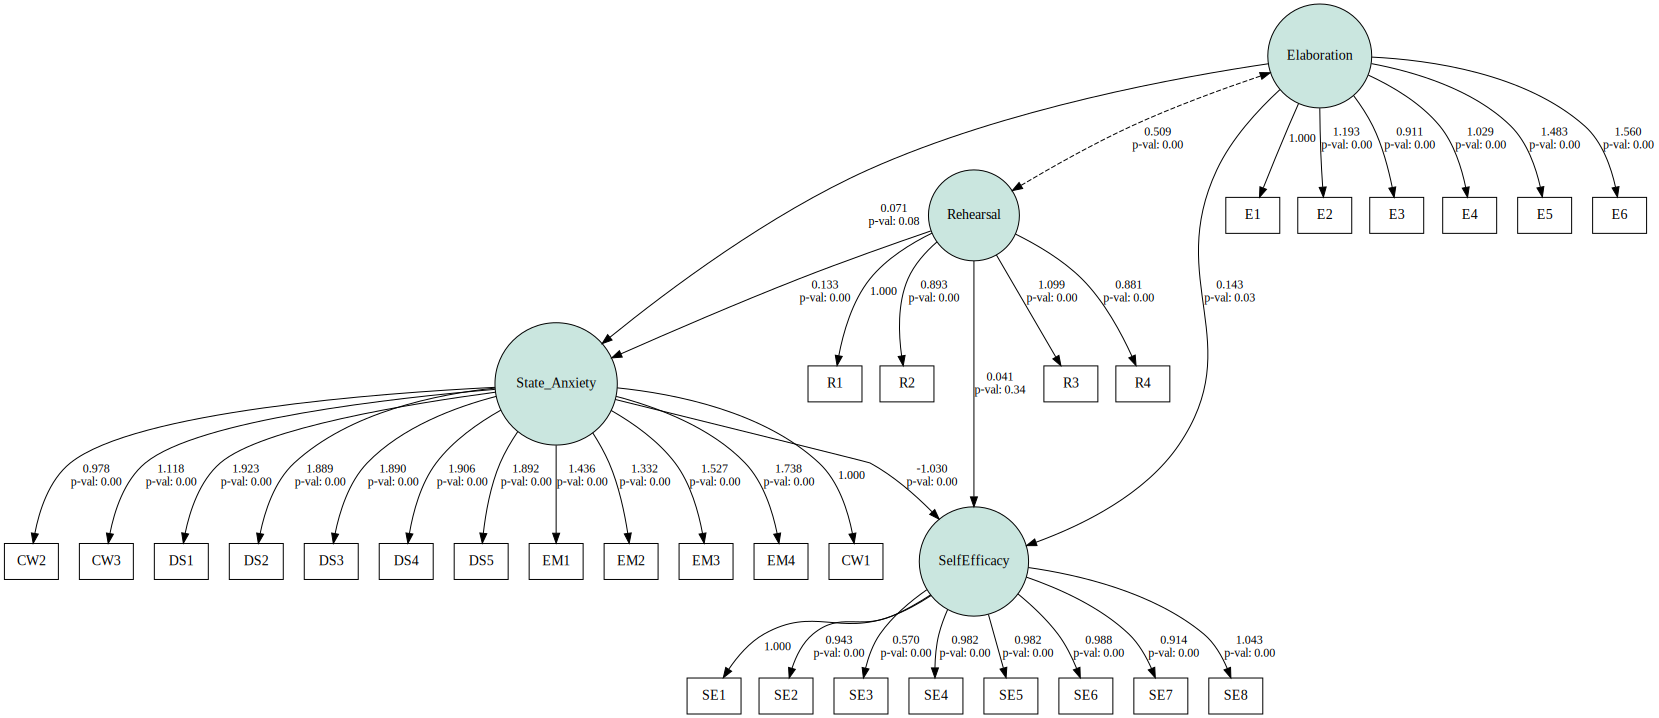

In [7]:
plot = semopy.semplot(model, "SEMmodel.png",plot_covs=True)
plot
